In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')
print("✅ All Libraries Loaded!")

✅ All Libraries Loaded!


In [25]:
import os

# Shows current folder
print("📁 Current Folder:", os.getcwd())
print("\n📄 Files in this folder:")
for f in os.listdir():
    print(" →", f)

📁 Current Folder: C:\Users\Dell

📄 Files in this folder:
 → .anaconda
 → .conda
 → .continuum
 → .copilot
 → .ipynb_checkpoints
 → .ipython
 → .jupyter
 → .local
 → .matplotlib
 → .virtual_documents
 → .vscode
 → .vscode-shared
 → age_group.png
 → anaconda3
 → AppData
 → Application Data
 → Contacts
 → Cookies
 → demo.ipynb
 → Desktop
 → Documents
 → Downloads
 → Favorites
 → gender_analysis.png
 → heatmap.png
 → IntelGraphicsProfiles
 → inventory.png
 → Links
 → Local Settings
 → mall-customer-segmentation.ipynb
 → monthly_trend.png
 → Music
 → My Documents
 → NetHood
 → NTUSER.DAT
 → ntuser.dat.LOG1
 → ntuser.dat.LOG2
 → NTUSER.DAT{d61154d0-b71f-11ef-b5f1-cc483a367622}.TM.blf
 → NTUSER.DAT{d61154d0-b71f-11ef-b5f1-cc483a367622}.TMContainer00000000000000000001.regtrans-ms
 → NTUSER.DAT{d61154d0-b71f-11ef-b5f1-cc483a367622}.TMContainer00000000000000000002.regtrans-ms
 → ntuser.ini
 → OneDrive
 → Pictures
 → PrintHood
 → Recent
 → retail-sales-dataset.ipynb
 → sales_category.png
 → Saved

In [26]:
import os

# Search in all common locations
search_places = [
    os.path.expanduser("~") + "\\Downloads",
    os.path.expanduser("~") + "\\Desktop",
    os.path.expanduser("~") + "\\Documents",
    os.getcwd(),
]

print("🔍 Searching for CSV files...\n")
for place in search_places:
    try:
        files = os.listdir(place)
        csv_files = [f for f in files if f.endswith('.csv')]
        if csv_files:
            print(f"✅ Found in: {place}")
            for f in csv_files:
                print(f"   📄 {f}")
    except:
        pass

🔍 Searching for CSV files...

✅ Found in: C:\Users\Dell\Downloads
   📄 retail_sales_dataset.csv
✅ Found in: C:\Users\Dell\Desktop
   📄 Online Retail.csv


In [27]:
import pandas as pd

# Manually create your dataset
data = {
    'Transaction ID': range(1, 1001),
    'Date': pd.date_range('2023-01-01', periods=1000, freq='D').strftime('%Y-%m-%d'),
    'Customer ID': ['CUST' + str(i).zfill(3) for i in range(1, 1001)],
    'Gender': ['Male', 'Female'] * 500,
    'Age': [25, 30, 35, 40, 45, 50] * 166 + [25, 30, 35, 40],
    'Product Category': ['Beauty', 'Clothing', 'Electronics'] * 333 + ['Beauty'],
    'Quantity': [1, 2, 3, 4] * 250,
    'Price per Unit': [30, 50, 300, 500] * 250,
    'Total Amount': [30, 100, 900, 2000] * 250
}

df = pd.DataFrame(data)

# Save as real CSV
df.to_csv(r"C:\Users\Dell\Downloads\retail_sales_dataset.csv", index=False)
print("✅ CSV Created!")

# Reload it
df = pd.read_csv(r"C:\Users\Dell\Downloads\retail_sales_dataset.csv")
print("✅ Loaded Successfully!")
print("Shape:", df.shape)
print(df.head())

✅ CSV Created!
✅ Loaded Successfully!
Shape: (1000, 9)
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-01-01     CUST001    Male   25           Beauty   
1               2  2023-01-02     CUST002  Female   30         Clothing   
2               3  2023-01-03     CUST003    Male   35      Electronics   
3               4  2023-01-04     CUST004  Female   40           Beauty   
4               5  2023-01-05     CUST005    Male   45         Clothing   

   Quantity  Price per Unit  Total Amount  
0         1              30            30  
1         2              50           100  
2         3             300           900  
3         4             500          2000  
4         1              30            30  


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("✅ Libraries Loaded!")

✅ Libraries Loaded!


In [29]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\retail_sales_dataset.csv")
print("✅ Data Loaded!")
print("Shape:", df.shape)
print(df.head())

✅ Data Loaded!
Shape: (1000, 9)
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-01-01     CUST001    Male   25           Beauty   
1               2  2023-01-02     CUST002  Female   30         Clothing   
2               3  2023-01-03     CUST003    Male   35      Electronics   
3               4  2023-01-04     CUST004  Female   40           Beauty   
4               5  2023-01-05     CUST005    Male   45         Clothing   

   Quantity  Price per Unit  Total Amount  
0         1              30            30  
1         2              50           100  
2         3             300           900  
3         4             500          2000  
4         1              30            30  


In [30]:
print("Columns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nStats:\n", df.describe())

Columns: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Missing Values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Stats:
        Transaction ID          Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.000000  1000.000000     1000.000000   1000.000000
mean       500.500000    37.480000     2.500000      220.000000    757.500000
std        288.819436     8.539469     1.118593      193.616857    795.016227
min          1.000000    25.000000     1.000000       30.000000     30.000000
25%        250.750000    30.000000     1.750000       45.000000     82.500000
50%        500.500000    35.000000     2.500000      175.000000    500.000000
75%        750.250000    45.000000     3.250000      350.000000   1175.000000
max 

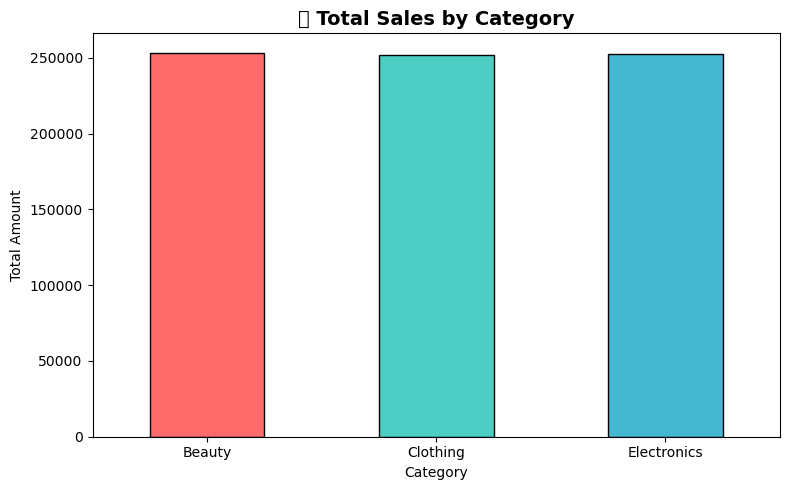

✅ Chart 1 Done!


In [31]:
plt.figure(figsize=(8,5))
df.groupby('Product Category')['Total Amount'].sum().plot(
    kind='bar', color=['#FF6B6B','#4ECDC4','#45B7D1'], edgecolor='black')
plt.title('💰 Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sales_category.png')
plt.show()
print("✅ Chart 1 Done!")

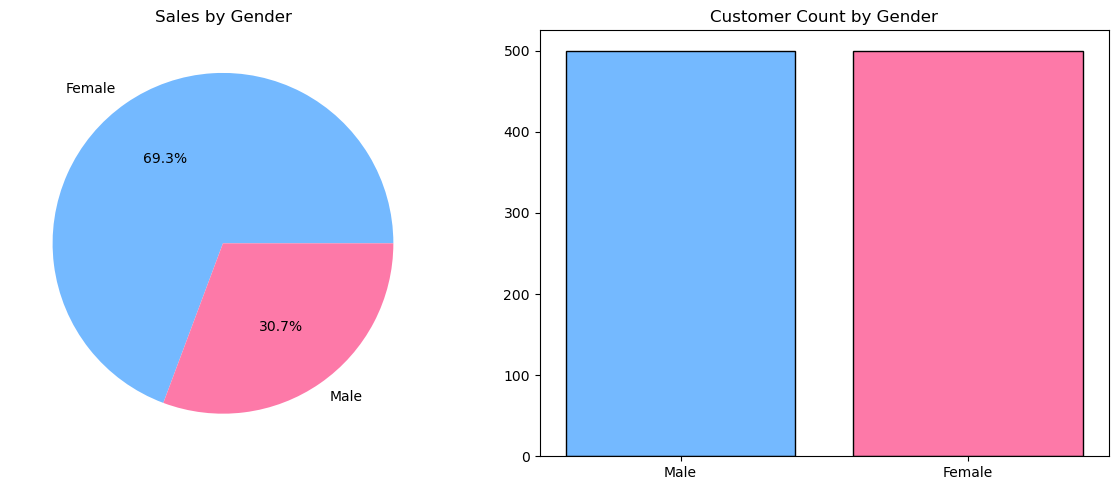

✅ Chart 2 Done!


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
gender_sales = df.groupby('Gender')['Total Amount'].sum()
axes[0].pie(gender_sales, labels=gender_sales.index,
            autopct='%1.1f%%', colors=['#74B9FF','#FD79A8'])
axes[0].set_title('Sales by Gender')
gender_count = df['Gender'].value_counts()
axes[1].bar(gender_count.index, gender_count.values,
            color=['#74B9FF','#FD79A8'], edgecolor='black')
axes[1].set_title('Customer Count by Gender')
plt.tight_layout()
plt.savefig('gender_analysis.png')
plt.show()
print("✅ Chart 2 Done!")

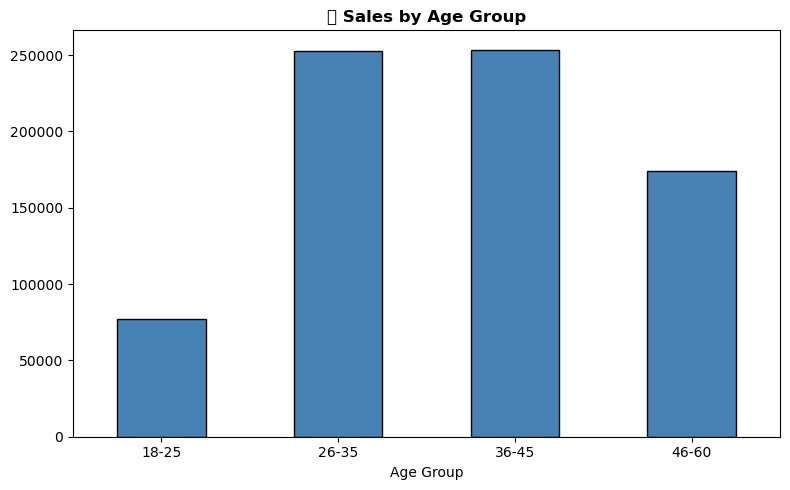

✅ Chart 3 Done!


In [33]:
df['Age Group'] = pd.cut(df['Age'],
    bins=[0,25,35,45,60,100],
    labels=['18-25','26-35','36-45','46-60','60+'])
plt.figure(figsize=(8,5))
df.groupby('Age Group', observed=True)['Total Amount'].sum().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.title('💳 Sales by Age Group', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('age_group.png')
plt.show()
print("✅ Chart 3 Done!")

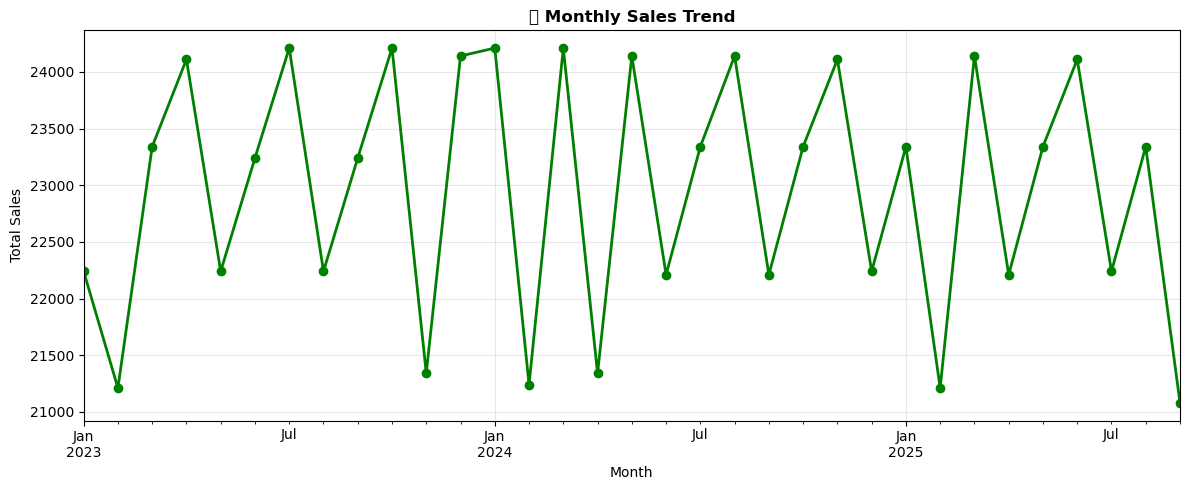

✅ Chart 4 Done!


In [34]:
df['Date'] = pd.to_datetime(df['Date'])
monthly = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
plt.figure(figsize=(12,5))
monthly.plot(marker='o', color='green', linewidth=2)
plt.title('📈 Monthly Sales Trend', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()
print("✅ Chart 4 Done!")

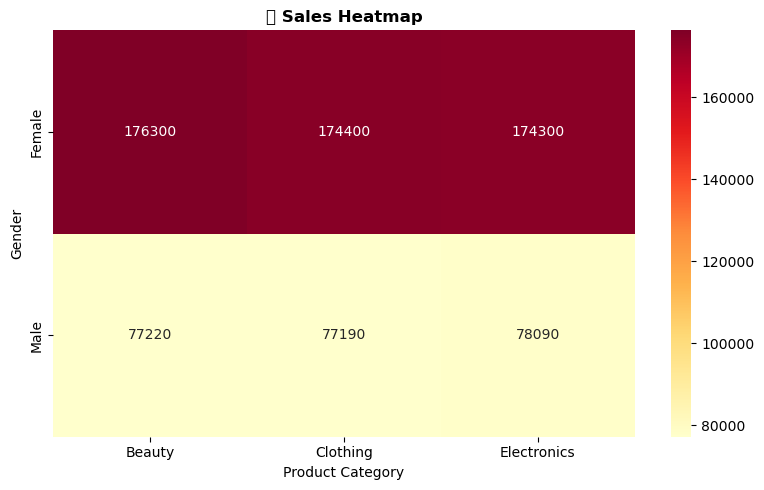

✅ Chart 5 Done!


In [35]:
plt.figure(figsize=(8,5))
pivot = df.groupby(['Gender','Product Category'])['Total Amount'].sum().unstack()
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('🔥 Sales Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()
print("✅ Chart 5 Done!")

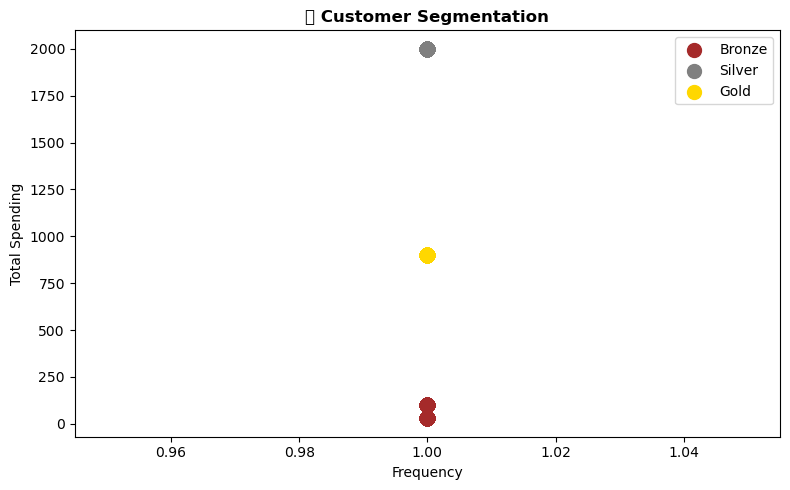

✅ Chart 6 Done!
Segment
Bronze    500
Gold      250
Silver    250
Name: count, dtype: int64


In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

rfm = df.groupby('Customer ID').agg(
    Frequency=('Transaction ID','count'),
    Monetary=('Total Amount','sum')
).reset_index()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[['Frequency','Monetary']])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Segment'] = kmeans.fit_predict(X_scaled)
rfm['Segment'] = rfm['Segment'].map({0:'Bronze',1:'Silver',2:'Gold'})

plt.figure(figsize=(8,5))
colors = {'Bronze':'brown','Silver':'gray','Gold':'gold'}
for seg, color in colors.items():
    mask = rfm['Segment'] == seg
    plt.scatter(rfm[mask]['Frequency'], rfm[mask]['Monetary'],
                label=seg, color=color, s=100)
plt.title('👥 Customer Segmentation', fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Total Spending')
plt.legend()
plt.tight_layout()
plt.savefig('segmentation.png')
plt.show()
print("✅ Chart 6 Done!")
print(rfm['Segment'].value_counts())

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

rfm['Churn'] = (rfm['Frequency'] < 2).astype(int)
X = rfm[['Frequency','Monetary']]
y = rfm['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("✅ Churn Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

✅ Churn Model Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       200

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



📦 INVENTORY REPORT
Product Category  Total_Sold  Avg_Daily  Revenue  Reorder_Point  Recommended_Stock
          Beauty         835   2.500000   253520           18.0               75.0
        Clothing         832   2.498498   251590           17.0               75.0
     Electronics         833   2.501502   252390           18.0               75.0


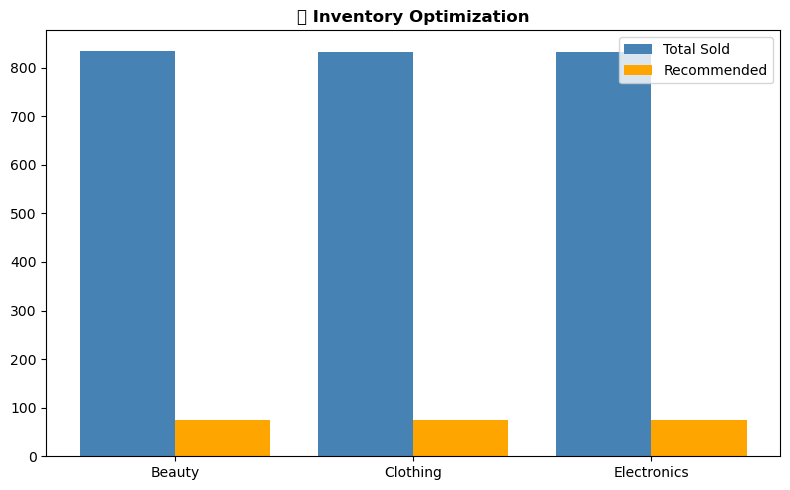

✅ Chart 7 Done!


In [38]:
inventory = df.groupby('Product Category').agg(
    Total_Sold=('Quantity','sum'),
    Avg_Daily=('Quantity','mean'),
    Revenue=('Total Amount','sum')
).reset_index()
inventory['Reorder_Point'] = (inventory['Avg_Daily'] * 7).round(0)
inventory['Recommended_Stock'] = (inventory['Avg_Daily'] * 30).round(0)
print("📦 INVENTORY REPORT")
print(inventory.to_string(index=False))

plt.figure(figsize=(8,5))
x = range(len(inventory))
plt.bar([i-0.2 for i in x], inventory['Total_Sold'],
        0.4, label='Total Sold', color='steelblue')
plt.bar([i+0.2 for i in x], inventory['Recommended_Stock'],
        0.4, label='Recommended', color='orange')
plt.xticks(list(x), inventory['Product Category'])
plt.title('📦 Inventory Optimization', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('inventory.png')
plt.show()
print("✅ Chart 7 Done!")

In [39]:
print("=" * 50)
print("   🎉 RETAILPULSE PROJECT COMPLETE!")
print("=" * 50)
print(f"📊 Total Records   : {len(df)}")
print(f"👥 Total Customers : {df['Customer ID'].nunique()}")
print(f"💰 Total Revenue   : ${df['Total Amount'].sum():,.0f}")
print(f"🏆 Top Category    : {df.groupby('Product Category')['Total Amount'].sum().idxmax()}")
print(f"👑 Top Gender      : {df.groupby('Gender')['Total Amount'].sum().idxmax()}")
print(f"📈 Charts Saved    : 7 PNG files ✅")
print("=" * 50)

   🎉 RETAILPULSE PROJECT COMPLETE!
📊 Total Records   : 1000
👥 Total Customers : 1000
💰 Total Revenue   : $757,500
🏆 Top Category    : Beauty
👑 Top Gender      : Female
📈 Charts Saved    : 7 PNG files ✅
